# 样本数据筛选notebook

## 这本notebook记录了数据筛选阶段尝试过的三种方法：整图效果分析法；船只分析法；框内框外对比法


In [1]:
import os, sys
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir))) # 数据路径
import paths

SPLITS = ['train', 'val']
IMG_ROOT   = os.path.dirname(paths.IMG_TRAIN)   # data/images  (train/ + val/)
LABEL_ROOT = paths.RAW_LBL_ROOT                 # data/raw/labels 
IMG_EXTS   = ('.jpg', '.jpeg', '.png')

os.makedirs('figures', exist_ok=True)          
assert os.path.isdir(os.path.join(IMG_ROOT, 'train')), (
    f'images not found under {IMG_ROOT}/train (expected the bundled data/ folder).')


In [2]:
def load_boxes(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 5:
                boxes.append(tuple(map(float, parts[:5])))
    return boxes


def extract_scaled_chip(img, cx, cy, w, h, theta, scale=1.5):

    H, W = img.shape[:2]
    cxp, cyp, wp, hp = cx * W, cy * H, w * W, h * H
    M = cv2.getRotationMatrix2D((cxp, cyp), math.degrees(theta), 1.0)
    rot = cv2.warpAffine(img, M, (W, H))
    cw, ch = int(round(wp * scale)), int(round(hp * scale))
    x0, y0 = int(round(cxp - cw / 2)), int(round(cyp - ch / 2))
    X0, Y0 = max(0, x0), max(0, y0)              # clamp to image bounds
    X1, Y1 = min(W, x0 + cw), min(H, y0 + ch)
    chip = rot[Y0:Y1, X0:X1]
    if chip.size == 0:
        return None, None
    ih, iw = chip.shape[:2]
    ccx, ccy = cxp - X0, cyp - Y0                # box centre within the chip
    mask = np.zeros((ih, iw), dtype=bool)
    ix0 = max(0, int(round(ccx - wp / 2))); ix1 = min(iw, int(round(ccx + wp / 2)))
    iy0 = max(0, int(round(ccy - hp / 2))); iy1 = min(ih, int(round(ccy + hp / 2)))
    mask[iy0:iy1, ix0:ix1] = True
    return chip, mask


def distinguishability(img, cx, cy, w, h, theta, scale=1.5): # 船只可识度
    chip, mask = extract_scaled_chip(img, cx, cy, w, h, theta, scale)
    if chip is None:
        return None
    inside, donut = mask, ~mask
    if inside.sum() < 9 or donut.sum() < 9:
        return None
    g = cv2.cvtColor(chip, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    gmag = np.sqrt(gx * gx + gy * gy)
    grad_in  = float(gmag[inside].mean())        # ship's own edge energy
    grad_out = float(gmag[donut].mean())         # surroundings' edge energy
    mean_in  = float(g[inside].mean())
    mean_out = float(g[donut].mean())
    std_out  = float(g[donut].std())
    return {
        'grad_in': grad_in,
        'grad_out': grad_out,
        'grad_ratio': grad_in / (grad_out + 1e-6),               # texture contrast
        'inten_z': abs(mean_in - mean_out) / (std_out + 1e-6),   # tonal silhouette
    }


def draw_donut_chip(img, cx, cy, w, h, theta, scale=1.5):
    """Visualization: the 1.5x chip with the inner (1.0x) box outlined in green."""
    chip, mask = extract_scaled_chip(img, cx, cy, w, h, theta, scale)
    if chip is None:
        return None
    chip = chip.copy()
    ys, xs = np.where(mask)
    if len(xs):
        cv2.rectangle(chip, (xs.min(), ys.min()), (xs.max(), ys.max()), (0, 255, 0), 2)
    return chip


### 第一种策略：模糊度、云雾量量化分析

whole-image filter would DROP 143/840 images


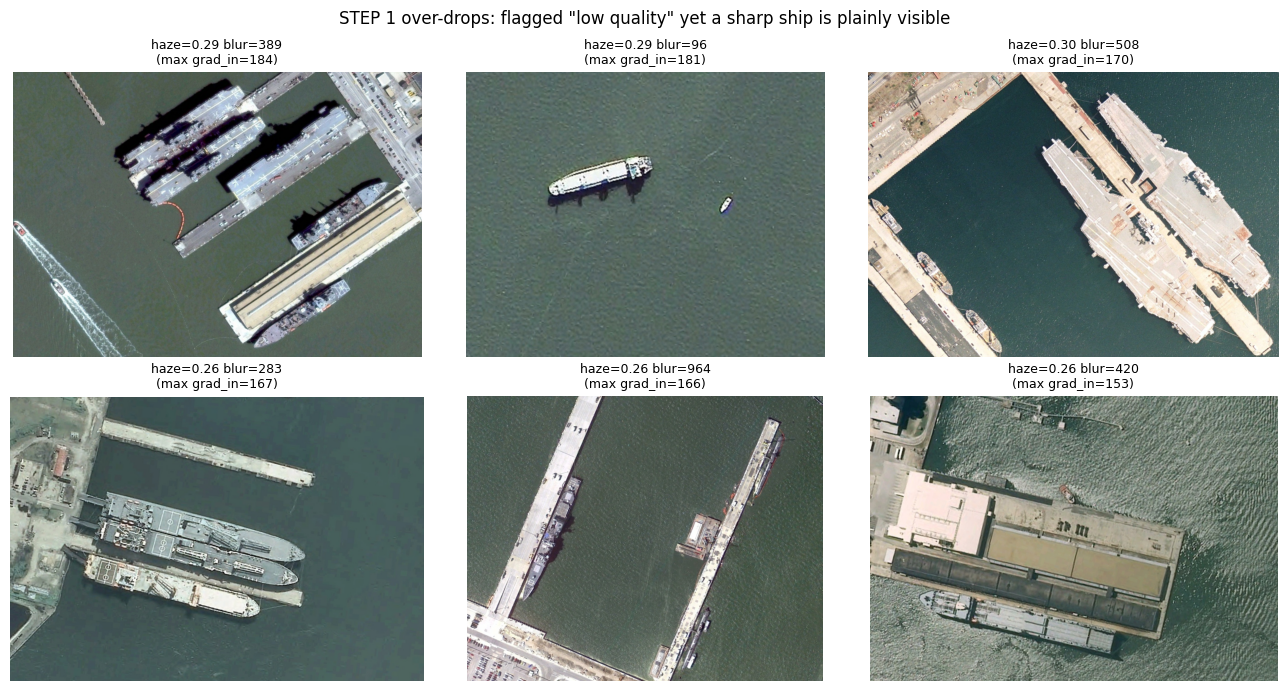

In [3]:
# ===== STEP 1 (rejected): whole-image haze + blur =====
def dark_channel_haze(img, patch=15):
    mn = img.min(axis=2).astype(np.float32)
    dark = cv2.erode(mn, np.ones((patch, patch), np.uint8))
    return float(dark.mean() / 255.0)                 # higher = hazier

def lap_blur(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())   # lower = blurrier

img_rows = []
for split in SPLITS:
    img_dir, lbl_dir = os.path.join(IMG_ROOT, split), os.path.join(LABEL_ROOT, split)
    if not os.path.isdir(img_dir):
        continue
    for name in sorted(f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS)):
        stem = os.path.splitext(name)[0]
        boxes = load_boxes(os.path.join(lbl_dir, stem + '.txt'))
        if not boxes:
            continue
        img = cv2.imread(os.path.join(img_dir, name))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gins = []
        for cx, cy, w, h, th in boxes:
            chip, mask = extract_scaled_chip(img, cx, cy, w, h, th)
            if chip is None:
                continue
            g = cv2.cvtColor(chip, cv2.COLOR_BGR2GRAY).astype(np.float32)
            gm = cv2.magnitude(cv2.Sobel(g, cv2.CV_32F, 1, 0, 3),
                               cv2.Sobel(g, cv2.CV_32F, 0, 1, 3))
            gins.append(float(gm[mask].mean()))
        img_rows.append(dict(split=split, name=name,
                             haze=dark_channel_haze(img), blur=lap_blur(gray),
                             max_grad_in=max(gins) if gins else 0.0))
idf = pd.DataFrame(img_rows)

haze_thr, blur_thr = idf['haze'].quantile(0.90), idf['blur'].quantile(0.10)
flagged1 = idf[(idf['haze'] >= haze_thr) | (idf['blur'] <= blur_thr)]
good_drop1 = flagged1.sort_values('max_grad_in', ascending=False).head(6)
print(f'whole-image filter would DROP {len(flagged1)}/{len(idf)} images')

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (_, r) in zip(axes.ravel(), good_drop1.iterrows()):
    im = cv2.imread(os.path.join(IMG_ROOT, r['split'], r['name']))
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f"haze={r['haze']:.2f} blur={r['blur']:.0f}\n(max grad_in={r['max_grad_in']:.0f})", fontsize=9)
    ax.axis('off')
fig.suptitle('STEP 1 over-drops: flagged "low quality" yet a sharp ship is plainly visible')
plt.tight_layout(); plt.savefig('figures/step1_overdrop.png', dpi=130, bbox_inches='tight'); plt.show()


### 第二种策略：框内船只是否可识别


FFT filter would DROP 239/2384 boxes


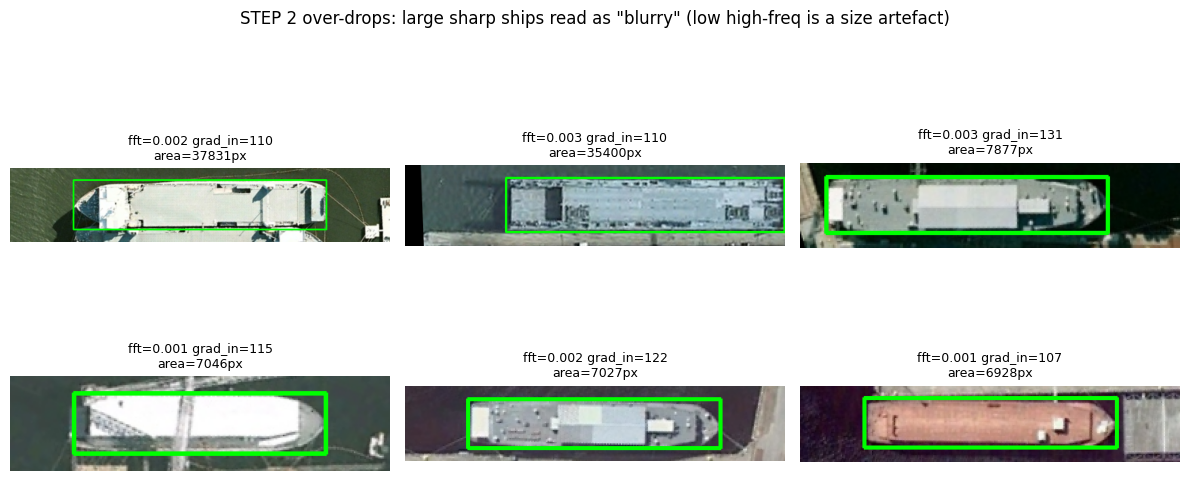

In [4]:
# ===== STEP 2 (rejected): per-box FFT high-freq + grad_in =====
def fft_highfreq_ratio(gray_chip, size=128, r_frac=0.25):
    if gray_chip is None or gray_chip.size == 0:
        return np.nan
    g = cv2.resize(gray_chip.astype(np.float32), (size, size))
    g = g * (np.hanning(size)[:, None] * np.hanning(size)[None, :])   # Hann window
    mag = np.abs(np.fft.fftshift(np.fft.fft2(g))) ** 2
    c = size // 2; yy, xx = np.ogrid[:size, :size]
    high = np.sqrt((yy - c) ** 2 + (xx - c) ** 2) > r_frac * size / 2
    return float(mag[high].sum() / (mag.sum() + 1e-9))                 # lower = blurrier

rows2 = []
for split in SPLITS:
    img_dir, lbl_dir = os.path.join(IMG_ROOT, split), os.path.join(LABEL_ROOT, split)
    if not os.path.isdir(img_dir):
        continue
    for name in sorted(f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS)):
        stem = os.path.splitext(name)[0]
        boxes = load_boxes(os.path.join(lbl_dir, stem + '.txt'))
        if not boxes:
            continue
        img = cv2.imread(os.path.join(img_dir, name))
        if img is None:
            continue
        H, W = img.shape[:2]
        for bi, (cx, cy, w, h, th) in enumerate(boxes):
            chip, mask = extract_scaled_chip(img, cx, cy, w, h, th)
            if chip is None:
                continue
            g = cv2.cvtColor(chip, cv2.COLOR_BGR2GRAY).astype(np.float32)
            gm = cv2.magnitude(cv2.Sobel(g, cv2.CV_32F, 1, 0, 3),
                               cv2.Sobel(g, cv2.CV_32F, 0, 1, 3))
            inner, _ = extract_scaled_chip(img, cx, cy, w, h, th, scale=1.0)
            fr = fft_highfreq_ratio(cv2.cvtColor(inner, cv2.COLOR_BGR2GRAY)) if inner is not None else np.nan
            rows2.append(dict(split=split, name=name, box_idx=bi, cx=cx, cy=cy, theta=th,
                              w=w, h=h, area_px=w * W * h * H,
                              grad_in=float(gm[mask].mean()), fft_ratio=fr))
f2 = pd.DataFrame(rows2).dropna(subset=['fft_ratio'])
fft_thr = f2['fft_ratio'].quantile(0.10)
flagged2 = f2[(f2['fft_ratio'] <= fft_thr) & (f2['grad_in'] > f2['grad_in'].median())]
good_drop2 = flagged2.sort_values('area_px', ascending=False).head(6)
print(f'FFT filter would DROP {int((f2["fft_ratio"] <= fft_thr).sum())}/{len(f2)} boxes')

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (_, r) in zip(axes.ravel(), good_drop2.iterrows()):
    im = cv2.imread(os.path.join(IMG_ROOT, r['split'], r['name']))
    chip, mask = extract_scaled_chip(im, r['cx'], r['cy'], r['w'], r['h'], r['theta'])
    chip = chip.copy(); ys, xs = np.where(mask)
    if len(xs):
        cv2.rectangle(chip, (xs.min(), ys.min()), (xs.max(), ys.max()), (0, 255, 0), 2)
    ax.imshow(cv2.cvtColor(chip, cv2.COLOR_BGR2RGB))
    ax.set_title(f"fft={r['fft_ratio']:.3f} grad_in={r['grad_in']:.0f}\narea={r['area_px']:.0f}px", fontsize=9)
    ax.axis('off')
fig.suptitle('STEP 2 over-drops: large sharp ships read as "blurry" (low high-freq is a size artefact)')
plt.tight_layout(); plt.savefig('figures/step2_overdrop.png', dpi=130, bbox_inches='tight'); plt.show()


### 第三种策略：框内框外对比

In [5]:
rows = []
for split in SPLITS:
    img_dir   = os.path.join(IMG_ROOT, split)
    label_dir = os.path.join(LABEL_ROOT, split)
    if not os.path.isdir(img_dir):
        print(f'(skip) no folder: {img_dir}')
        continue
    names = sorted(f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS))
    n_imgs = n_box = 0
    for name in names:
        stem = os.path.splitext(name)[0]
        boxes = load_boxes(os.path.join(label_dir, stem + '.txt'))
        if not boxes:
            continue                       # no ship -> nothing to score
        img = cv2.imread(os.path.join(img_dir, name), cv2.IMREAD_COLOR)
        if img is None:
            print(f'(unreadable) {split}/{name}')
            continue
        H, W = img.shape[:2]
        n_imgs += 1
        for bi, (cx, cy, w, h, theta) in enumerate(boxes):
            m = distinguishability(img, cx, cy, w, h, theta)
            if m is None:
                continue
            m.update({
                'split': split, 'name': name, 'box_idx': bi,
                'cx': cx, 'cy': cy, 'theta': theta,
                'box_w_px': round(w * W, 1), 'box_h_px': round(h * H, 1),
            })
            rows.append(m)
            n_box += 1
    print(f'{split}: {n_imgs} images with ships, {n_box} boxes scored')

boxes_df = pd.DataFrame(rows)[
    ['split', 'name', 'box_idx', 'box_w_px', 'box_h_px',
     'grad_in', 'grad_out', 'grad_ratio', 'inten_z',
     'cx', 'cy', 'theta']]
boxes_df.to_csv('ship_quality_boxes.csv', index=False)
print(f'\nSaved ship_quality_boxes.csv — {len(boxes_df)} ship rows')
boxes_df.head()

train: 714 images with ships, 2014 boxes scored
val: 126 images with ships, 370 boxes scored

Saved ship_quality_boxes.csv — 2384 ship rows


,split,name,box_idx,box_w_px,box_h_px,grad_in,grad_out,grad_ratio,inten_z,cx,cy,theta
0,train,100000001.jpg,0,778.1,174.3,32.124355,18.489643,1.737424,1.455397,0.499944,0.469058,-0.214431
1,train,100000002.jpg,0,777.2,189.8,38.919117,16.018843,2.429583,2.045138,0.456095,0.484592,1.078961
2,train,100000003.jpg,0,718.5,170.1,31.534777,19.579008,1.610642,1.362632,0.559466,0.635693,0.341886
3,train,100000005.jpg,0,771.1,178.8,39.148952,27.168011,1.440994,1.192024,0.650923,0.685157,-0.095200
4,train,100000006.jpg,0,778.4,178.3,35.446934,18.368698,1.929747,0.752806,0.291138,0.543300,-1.122944


## 数据筛选（三个指标）

In [6]:
DROP_PCTL     = 0.10   
GRAD_IN_FLOOR = 18.0  
CUES = ['grad_in', 'grad_ratio', 'inten_z']   # higher = more distinguishable
thresholds = {c: boxes_df[c].quantile(DROP_PCTL) for c in CUES}
for c in CUES:
    boxes_df[f'weak_{c}'] = boxes_df[c] < thresholds[c]

all_cues_weak = boxes_df[[f'weak_{c}' for c in CUES]].all(axis=1)   # blended into surroundings
dead_structure = boxes_df['grad_in'] < GRAD_IN_FLOOR               # fogged out, no structure
boxes_df['dead_structure'] = dead_structure
boxes_df['unobservable'] = all_cues_weak | dead_structure
# strongest available cue (as a percentile) — handy for ranking the worst ships
boxes_df['best_cue_pctl'] = boxes_df[CUES].rank(pct=True).max(axis=1)

print('weak-cue thresholds (bottom {:.0%}):'.format(DROP_PCTL))
for c in CUES:
    print(f'  {c:11s} < {thresholds[c]:.3f}')
print('\nweak-cue counts:')
print(boxes_df[[f'weak_{c}' for c in CUES]].sum())
print(f'\n  all-cues-weak (blended)      : {int(all_cues_weak.sum())}')
print(f'  dead-structure (grad_in<{GRAD_IN_FLOOR:g}) : {int(dead_structure.sum())}')
print(f'\nUndetectable ships (either rule): {boxes_df["unobservable"].sum()} / {len(boxes_df)} '
      f'({100 * boxes_df["unobservable"].mean():.1f}%)')
boxes_df.to_csv('ship_quality_boxes.csv', index=False)

weak-cue thresholds (bottom 10%):
  grad_in     < 61.831
  grad_ratio  < 1.207
  inten_z     < 0.172

weak-cue counts:
weak_grad_in       239
weak_grad_ratio    239
weak_inten_z       239
dtype: int64

  all-cues-weak (blended)      : 18
  dead-structure (grad_in<18) : 2

Undetectable ships (either rule): 20 / 2384 (0.8%)


## 第三种策略的筛选结果


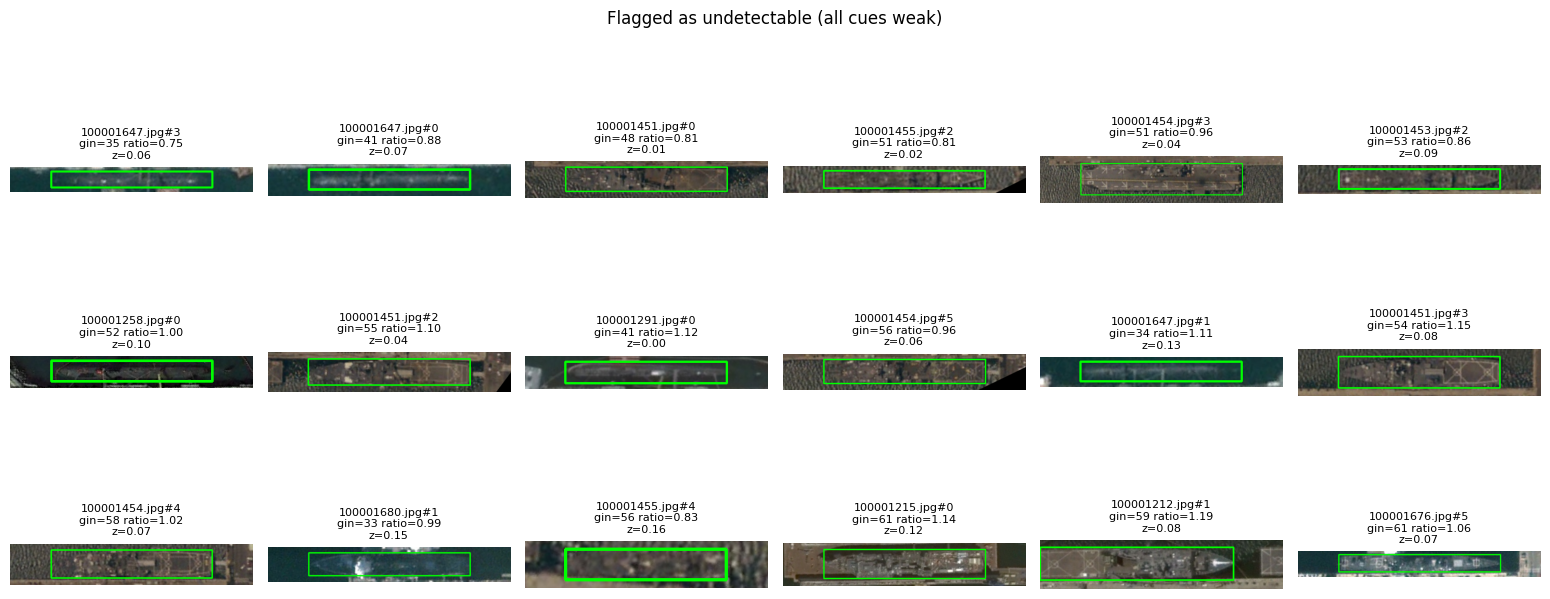

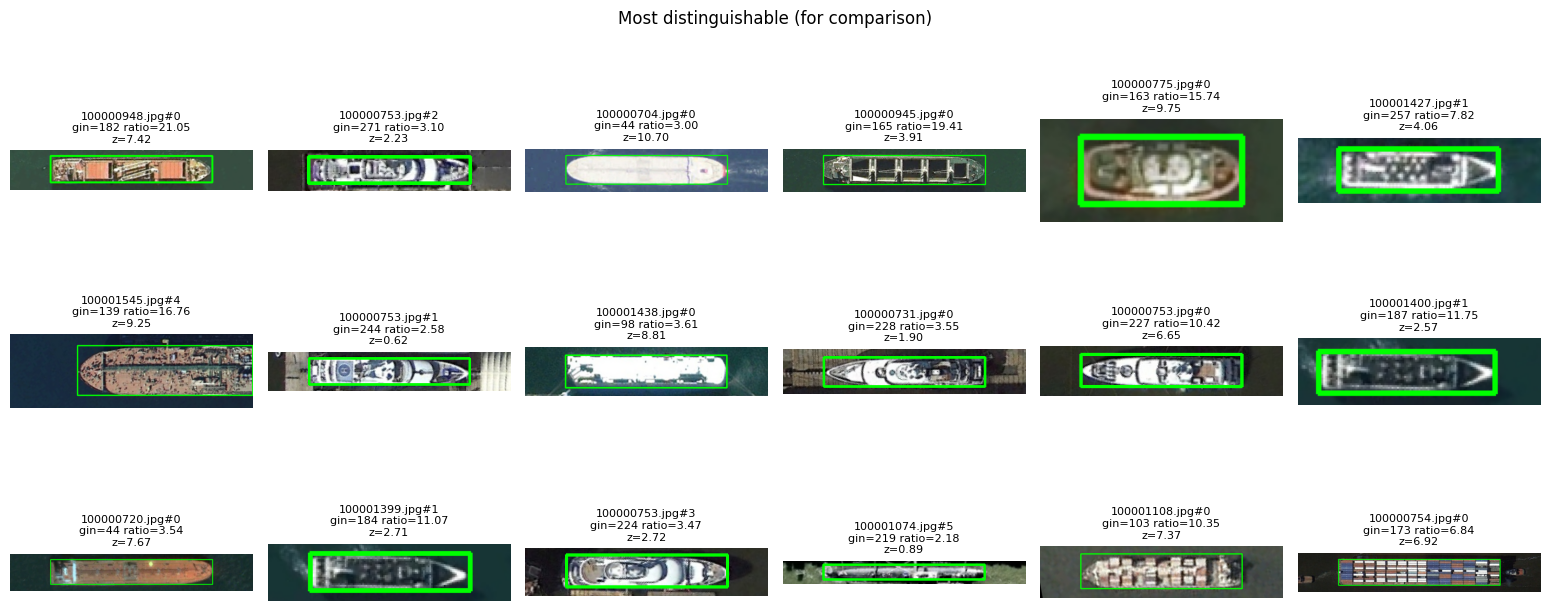

In [7]:
def show_donut_chips(sub, title, k=18, cols=6):
    sub = sub.head(k)
    if len(sub) == 0:
        print(f'(none) {title}')
        return
    rows_n = int(np.ceil(len(sub) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(2.6 * cols, 2.4 * rows_n))
    for ax, (_, r) in zip(np.array(axes).ravel(), sub.iterrows()):
        img = cv2.imread(os.path.join(IMG_ROOT, r['split'], r['name']))
        chip = draw_donut_chip(img, r['cx'], r['cy'],
                               r['box_w_px'] / img.shape[1], r['box_h_px'] / img.shape[0],
                               r['theta'])
        ax.imshow(cv2.cvtColor(chip, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{r['name']}#{r['box_idx']}\n"
                     f"gin={r['grad_in']:.0f} ratio={r['grad_ratio']:.2f}\n"
                     f"z={r['inten_z']:.2f}", fontsize=8)
        ax.axis('off')
    for ax in np.array(axes).ravel()[len(sub):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# the flagged (undetectable) ships, worst first
show_donut_chips(boxes_df[boxes_df['unobservable']].sort_values('best_cue_pctl'),
                 'Flagged as undetectable (all cues weak)')
# for comparison: the most distinguishable ships (should look obviously sharp/contrasty)
show_donut_chips(boxes_df.sort_values('best_cue_pctl', ascending=False),
                 'Most distinguishable (for comparison)')

## 误删好图

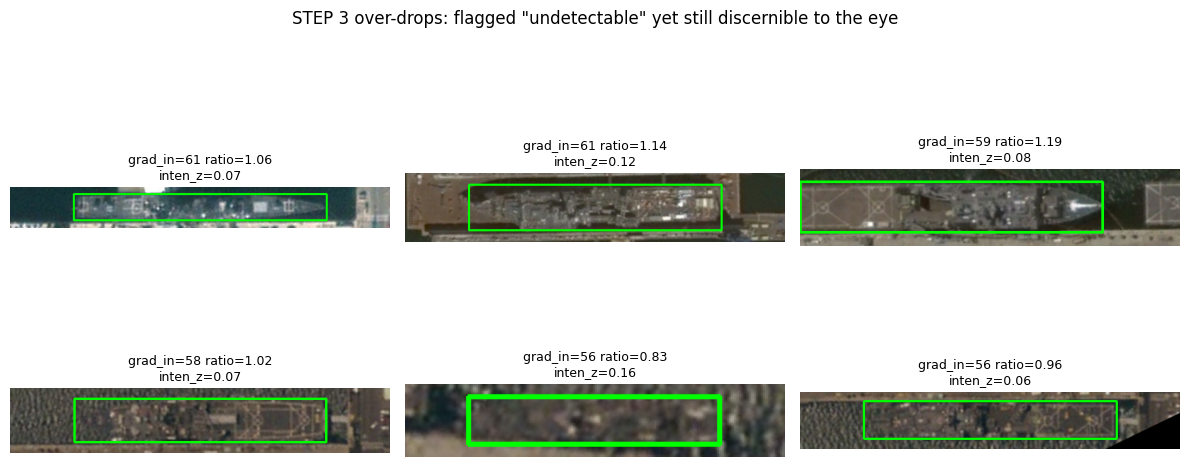

In [8]:
# ===== STEP 3 over-drops: even the adopted rule flags some discernible ships =====
flagged3 = boxes_df[boxes_df['unobservable']].sort_values('grad_in', ascending=False).head(6)
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (_, r) in zip(axes.ravel(), flagged3.iterrows()):
    im = cv2.imread(os.path.join(IMG_ROOT, r['split'], r['name']))
    chip = draw_donut_chip(im, r['cx'], r['cy'],
                           r['box_w_px'] / im.shape[1], r['box_h_px'] / im.shape[0], r['theta'])
    ax.imshow(cv2.cvtColor(chip, cv2.COLOR_BGR2RGB))
    ax.set_title(f"grad_in={r['grad_in']:.0f} ratio={r['grad_ratio']:.2f}\ninten_z={r['inten_z']:.2f}", fontsize=9)
    ax.axis('off')
fig.suptitle('STEP 3 over-drops: flagged "undetectable" yet still discernible to the eye')
plt.tight_layout(); plt.savefig('figures/step3_overdrop.png', dpi=130, bbox_inches='tight'); plt.show()
